In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [4]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [5]:
df.duplicated().sum()

np.int64(2)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

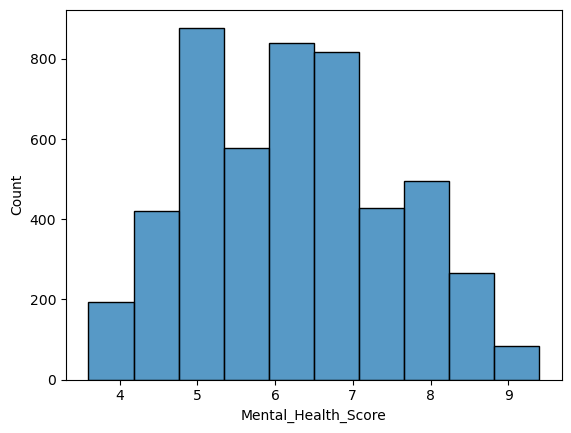

In [6]:
sns.histplot(df['Mental_Health_Score'],bins=10)

<Axes: >

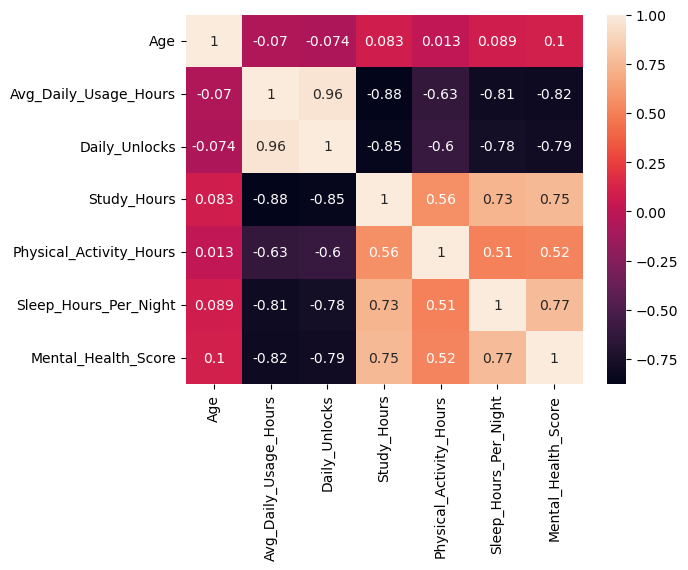

In [7]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

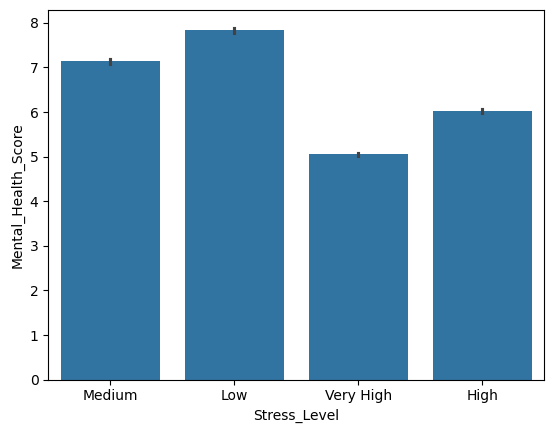

In [8]:
sns.barplot(
    x='Stress_Level',
    y='Mental_Health_Score',
    data=df
)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

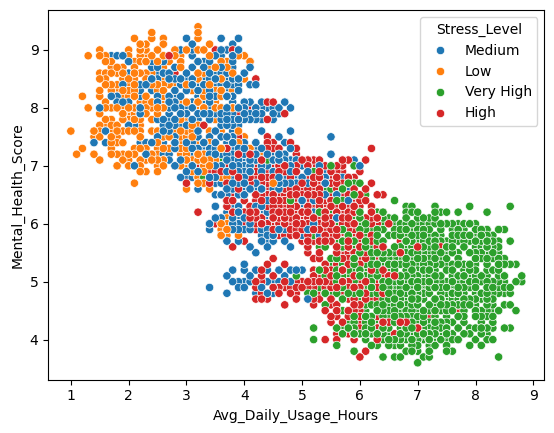

In [9]:
sns.scatterplot(data=df,x="Avg_Daily_Usage_Hours" , y="Mental_Health_Score" ,hue=df["Stress_Level"] )

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Sleep_Hours_Per_Night'>

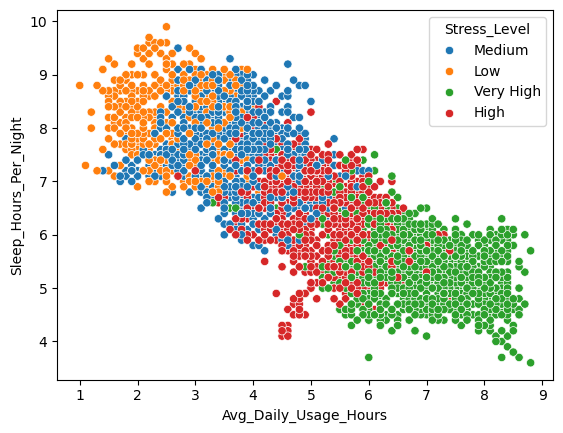

In [10]:
sns.scatterplot(data=df,x="Avg_Daily_Usage_Hours" , y="Sleep_Hours_Per_Night" ,hue=df["Stress_Level"] )

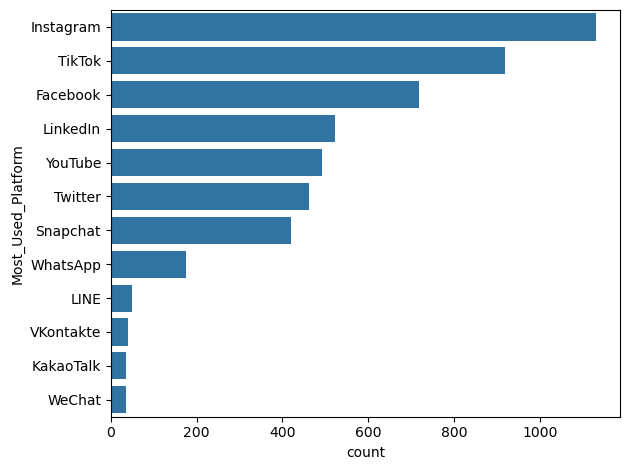

In [11]:
sns.countplot(df["Most_Used_Platform"],order=df['Most_Used_Platform'].value_counts().index)
plt.tight_layout()

In [12]:
num_features = df.select_dtypes(include="number")
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [13]:
q1 = num_features.quantile(0.25)
q3 = num_features.quantile(0.75)
IQR = q3 - q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR
outliers = (num_features>upper_bound) | (num_features < lower_bound)
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

In [14]:
df = df.drop_duplicates()
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [15]:
num_features.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

In [16]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [17]:
def group_country(country):
    if country in top_countries:
        return country
    else:
        return "Other"

In [18]:
df['Grouped_Country'] = df['Country'].apply(group_country)
df['Grouped_Country'].value_counts()

Grouped_Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [19]:
skwed_cols = ['Study_Hours']
other_numeric_cols = ['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night']
ordinal_col = ['Stress_Level']
normal_cols = ['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_Country']

feature_col = skwed_cols + other_numeric_cols + ordinal_col + normal_cols
X = df[feature_col]
y = df['Mental_Health_Score']

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler' , StandardScaler())
    ])

plain_pipeline = Pipeline(steps=[
    ('scaler' , StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode' , OrdinalEncoder(categories=[['Low' , 'Medium' , 'High' , 'Very High']]))
])

normal_pipeline = Pipeline(steps=[
    ('encode' , OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('Skewed_pipeline' , skew_pipeline , skwed_cols),
    ('Plain_pipeline' , plain_pipeline , other_numeric_cols),
    ('Ordinal_pipeline' , ordinal_pipeline , ordinal_col),
    ('Normal_pipeline' , normal_pipeline , normal_cols)
])

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7,random_state=42)
X_train.shape

(3498, 12)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regression' , LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_training = lr_pipeline.predict(X_train)

lr_r2_test = r2_score(y_test,lr_pred)
lr_r2_training = r2_score(y_train , lr_pred_training)
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_mse = mean_squared_error(y_test,lr_pred)

print(f"Accuracy of training data : {lr_r2_training}")
print(f"Accuracy of testing data : {lr_r2_test}")
print(f"MAE : {lr_mae}")
print(f"MSE : {lr_mse}")


Accuracy of training data : 0.7236771199387538
Accuracy of testing data : 0.739794461743302
MAE : 0.5361775634720183
MSE : 0.45701905273488


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor' , preprocessor),
    ('random forest' , RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

rf_r2_test = r2_score(y_test,rf_pred)
rf_r2_train = r2_score(y_train , rf_pred_train)
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)

print(f"Accuracy of training data : {rf_r2_train}")
print(f"Accuracy of testing data : {rf_r2_test}")
print(f"MAE : {rf_mae}")
print(f"MSE : {rf_mse}")

Accuracy of training data : 0.9808287942404612
Accuracy of testing data : 0.8775888638668996
MAE : 0.34722113333333343
MSE : 0.21500011819333337


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators' : [100,200,300],
    'random forest__max_depth' : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf' : [1,2,4]
}

random_search = RandomizedSearchCV(estimator=rf_pipeline , param_distributions= param_grid , n_iter=15,cv=5,scoring='r2',random_state=42,n_jobs=-1)

random_search.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)
rf_best_preds_train = rf_best_pipeline.predict(X_train)
print(f"R2 score after hyper parameter tunning : {r2_score(y_test,rf_best_preds)}")
print(f"R2 score for X_train after hyper parameter tunning : {r2_score(y_train,rf_best_preds_train)}")

R2 score after hyper parameter tunning : 0.8650140569761653
R2 score for X_train after hyper parameter tunning : 0.9547027344112449


In [26]:
import joblib
joblib.dump(rf_pipeline,"Mental_Health_Model.pkl")

['Mental_Health_Model.pkl']